Check if file exists

In [ ]:
import os

os.listdir("/content")

['.config', 'sample_data']

Upload the dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving city_day.csv to city_day.csv


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'city_day.csv', 'sample_data']


Read the file

In [ ]:
df = pd.read_csv("city_day.csv")

print(df.shape)
df.head()

(29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


Exploratory Data Analysis (EDA)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("city_day.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73
Benzene,23908.0,3.280840,15.811136,0.00,0.120,1.07,3.0800,455.03


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
Xylene,18109
PM10,11140
NH3,10328
Toluene,8041
Benzene,5623
AQI,4681
AQI_Bucket,4681
PM2.5,4598
NOx,4185
O3,4022


In [ ]:
df["City"].value_counts()

,count
City,
Ahmedabad,2009
Bengaluru,2009
Chennai,2009
Mumbai,2009
Lucknow,2009
Delhi,2009
Hyderabad,2006
Patna,1858
Gurugram,1679


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 2015-01-01 00:00:00
End Date: 2020-07-01 00:00:00


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


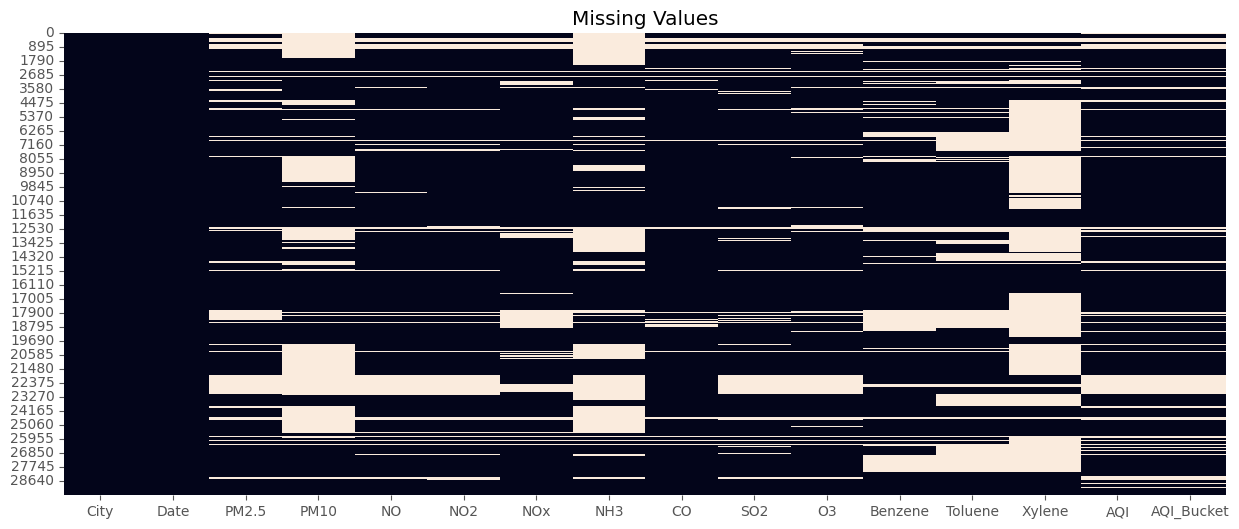

In [ ]:
plt.figure(figsize=(15,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

Which cities have the best data quality?


Which cities are sufficiently different to make the generalization experiment interesting?

In [ ]:
city_missing = (
    df.groupby("City")
      .apply(lambda x: x.isnull().mean() * 100)
      .round(1)
)

city_missing[
    ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", "NH3"]
]

,PM2.5,PM10,NO2,SO2,CO,O3,NH3
City,,,,,,,
Ahmedabad,31.3,79.7,30.3,31.9,30.3,34.1,100.0
Aizawl,1.8,0.9,0.0,0.0,0.0,8.0,0.0
Amaravati,6.2,5.8,5.8,6.8,10.2,5.8,5.8
Amritsar,10.5,5.2,3.6,13.8,6.2,9.4,3.4
Bengaluru,7.3,17.9,0.3,0.3,0.5,7.2,10.1
Bhopal,3.1,3.1,3.1,3.1,3.1,3.1,3.1
Brajrajnagar,19.7,18.4,24.9,20.6,16.0,21.6,24.1
Chandigarh,4.9,0.0,1.3,0.0,0.0,0.0,3.3
Chennai,5.8,85.0,1.8,1.8,1.2,2.4,23.0


In [ ]:
df.groupby("City")["PM2.5"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
City,,,,,,,,
Ahmedabad,1381.0,67.85,39.49,3.04,39.43,58.37,87.18,381.69
Aizawl,111.0,17.13,15.29,0.16,3.76,10.48,29.20,54.90
Amaravati,892.0,37.77,27.26,4.65,17.06,28.02,52.74,139.38
Amritsar,1093.0,55.47,51.39,2.85,31.68,44.09,63.67,868.66
Bengaluru,1863.0,35.82,22.07,1.72,21.30,30.92,44.25,313.59
Bhopal,280.0,50.06,30.43,3.40,23.07,44.84,70.11,136.42
Brajrajnagar,753.0,64.06,36.17,2.54,34.26,60.63,86.20,308.79
Chandigarh,289.0,41.13,28.21,6.86,19.17,33.27,53.96,154.85
Chennai,1892.0,50.43,26.70,6.55,33.28,45.54,61.50,293.43


PREPROCESSING

Create a copy of the data

In [ ]:
# Make a working copy
df_clean = df.copy()

Convert the date column

In [ ]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

In [ ]:
df_clean.dtypes

,0
City,object
Date,datetime64[ns]
PM2.5,float64
PM10,float64
NO,float64
NO2,float64
NOx,float64
NH3,float64
CO,float64
SO2,float64


Drop Xylene

In [ ]:
df_clean = df_clean.drop(columns=["Xylene"])

Check the remaining missing values

- We'll use this to decide how to treat the remaining missing values instead of applying one rule to every column.

In [ ]:
(df_clean.isnull().mean() * 100).sort_values(ascending=False)

,0
PM10,37.723071
NH3,34.973418
Toluene,27.229014
Benzene,19.041008
AQI,15.851139
AQI_Bucket,15.851139
PM2.5,15.570079
NOx,14.171549
O3,13.619586
SO2,13.050692


Clean the Data Properly

Sort by City and Date

In [ ]:
df_clean = df_clean.sort_values(["City", "Date"]).reset_index(drop=True)

Drop AQI Columns

In [ ]:
df_clean = df_clean.drop(columns=["AQI", "AQI_Bucket"])

City-wise Interpolation

- This fills missing values using neighboring observations within the same city

In [ ]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns

df_clean[numeric_cols] = (
    df_clean.groupby("City")[numeric_cols]
            .transform(lambda x: x.interpolate(method="linear"))
)

Fill Remaining Gaps

In [ ]:
df_clean[numeric_cols] = (
    df_clean.groupby("City")[numeric_cols]
            .transform(lambda x: x.ffill().bfill())
)

Verify

In [ ]:
(df_clean.isnull().sum()).sort_values(ascending=False)

,0
Toluene,4010
Benzene,2732
NH3,2009
PM10,2009
NOx,1169
O3,162
PM2.5,0
Date,0
City,0
NO,0


Feature Engineering

Date Features

In [ ]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Day"] = df_clean["Date"].dt.day
df_clean["DayOfWeek"] = df_clean["Date"].dt.dayofweek
df_clean["WeekOfYear"] = df_clean["Date"].dt.isocalendar().week.astype(int)

Lag Features

In [ ]:
df_clean["PM2.5_Lag1"] = (
    df_clean.groupby("City")["PM2.5"].shift(1)
)

df_clean["PM2.5_Lag7"] = (
    df_clean.groupby("City")["PM2.5"].shift(7)
)

Rolling Mean

In [ ]:
df_clean["PM2.5_Rolling7"] = (
    df_clean.groupby("City")["PM2.5"]
            .transform(lambda x: x.rolling(7).mean())
)

Check Missing Values Again

In [ ]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
Toluene,4010
Benzene,2732
NH3,2009
PM10,2009
NOx,1169
PM2.5_Lag7,182
O3,162
PM2.5_Rolling7,156
PM2.5_Lag1,26
NO,0


Remove Initial Rows with Missing Engineered Features

In [ ]:
df_model = df_clean.dropna().reset_index(drop=True)

print(df_model.shape)
df_model.head()

(21060, 21)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Year,Month,Day,DayOfWeek,WeekOfYear,PM2.5_Lag1,PM2.5_Lag7,PM2.5_Rolling7
0,Aizawl,2020-03-18,31.76,41.51,3.00,1.48,5.24,23.42,0.47,5.04,8.76,0.24,1.19,2020,3,18,2,12,27.32,32.69,33.267143
1,Aizawl,2020-03-19,43.80,53.59,2.97,1.31,4.97,23.41,0.48,5.30,9.96,0.26,1.11,2020,3,19,3,12,31.76,31.21,35.065714
2,Aizawl,2020-03-20,35.48,44.02,3.01,0.83,4.64,24.85,0.49,5.32,6.43,0.27,1.15,2020,3,20,4,12,43.80,38.39,34.650000
3,Aizawl,2020-03-21,51.27,60.05,3.01,0.88,4.62,24.44,0.49,5.63,8.62,49.66,50.11,2020,3,21,5,12,35.48,43.23,35.798571
4,Aizawl,2020-03-22,33.24,40.33,2.93,0.13,3.65,18.55,0.37,5.41,5.64,13.07,13.69,2020,3,22,6,12,51.27,33.82,35.715714


✅ Better Approach

In [ ]:
features = [
    "City",
    "Date",
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "CO",
    "SO2",
    "O3",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "PM2.5_Lag1",
    "PM2.5_Lag7",
    "PM2.5_Rolling7"
]

df_model = df_clean[features].copy()

check missing values:

In [ ]:
df_model.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,2009
NO,0
NO2,0
NOx,1169
CO,0
SO2,0
O3,162


In [ ]:
df_model = df_model.dropna(
    subset=[
        "PM2.5",
        "PM2.5_Lag1",
        "PM2.5_Lag7",
        "PM2.5_Rolling7"
    ]
)

Check the dataset

- There may still be missing values in columns like PM10 or NOx, and that's okay for now—we'll decide how to handle them after checking.

In [ ]:
print("Shape:", df_model.shape)

df_model.isnull().sum()

Shape: (29349, 18)


,0
City,0
Date,0
PM2.5,0
PM10,2002
NO,0
NO2,0
NOx,1162
CO,0
SO2,0
O3,155


Decide the input features

In [ ]:
feature_cols = [
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "CO",
    "SO2",
    "O3",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "PM2.5_Lag1",
    "PM2.5_Lag7",
    "PM2.5_Rolling7"
]

target = "PM2.5"

Check if any selected features still have missing values

In [ ]:
df_model[feature_cols].isnull().sum().sort_values(ascending=False)

,0
PM10,2002
NOx,1162
O3,155
NO2,0
NO,0
CO,0
SO2,0
Year,0
Month,0
Day,0


Impute only the remaining missing values.

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df_model[["PM10", "NOx", "O3"]] = imputer.fit_transform(
    df_model[["PM10", "NOx", "O3"]]
)

In [ ]:
df_model.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
CO,0
SO2,0
O3,0


MACHINE LEARNING PART

Create train and test sets

In [ ]:
train_city = "Delhi"
test_cities = ["Bengaluru", "Chennai", "Kolkata"]

train_df = df_model[df_model["City"] == train_city].copy()

test_df = df_model[df_model["City"].isin(test_cities)].copy()

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

print(test_df["City"].value_counts())

Training Shape: (2002, 18)
Testing Shape: (4811, 18)
City
Bengaluru    2002
Chennai      2002
Kolkata       807
Name: count, dtype: int64


In [ ]:
feature_cols = [
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "CO",
    "SO2",
    "O3",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "PM2.5_Lag1",
    "PM2.5_Lag7",
    "PM2.5_Rolling7"
]

target = "PM2.5"

In [ ]:
X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

print(X_train.shape)
print(X_test.shape)

(2002, 15)
(4811, 15)


Sort Delhi chronologically

In [ ]:
train_df = train_df.sort_values("Date").reset_index(drop=True)

Create a time-based split

In [ ]:
split_index = int(len(train_df) * 0.8)

train_split = train_df.iloc[:split_index]
val_split = train_df.iloc[split_index:]

Create training and validation sets

In [ ]:
X_train = train_split[feature_cols]
y_train = train_split[target]

X_val = val_split[feature_cols]
y_val = val_split[target]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (1601, 15)
Validation: (401, 15)


Scale the data (only for Linear Regression and Ridge)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

Train your Baseline Model (Linear Regression)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

Make predictions

In [ ]:
y_pred = lr.predict(X_val_scaled)

Evaluate

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 16.94
RMSE : 26.45
R²   : 0.8910


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_val, y_pred)

print(f"MAPE : {mape*100:.2f}%")

MAPE : 21.62%


Save Linear Regression Results

In [ ]:
linear_results = {
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "R2": r2
}

Ridge Regression

Import Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

Create and Train the Model

In [ ]:
ridge = Ridge(alpha=1.0, random_state=42)

ridge.fit(X_train_scaled, y_train)

Ridge(random_state=42)

Make Predictions

In [ ]:
ridge_pred = ridge.predict(X_val_scaled)

Evaluate the Model

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

ridge_mae = mean_absolute_error(y_val, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_pred))
ridge_mape = mean_absolute_percentage_error(y_val, ridge_pred)
ridge_r2 = r2_score(y_val, ridge_pred)

print(f"MAE  : {ridge_mae:.2f}")
print(f"RMSE : {ridge_rmse:.2f}")
print(f"MAPE : {ridge_mape*100:.2f}%")
print(f"R²   : {ridge_r2:.4f}")

MAE  : 16.93
RMSE : 26.45
MAPE : 21.59%
R²   : 0.8910


Save the Results

In [ ]:
ridge_results = {
    "Model": "Ridge Regression",
    "MAE": ridge_mae,
    "RMSE": ridge_rmse,
    "MAPE": ridge_mape,
    "R2": ridge_r2
}

print(ridge_results)

{'Model': 'Ridge Regression', 'MAE': 16.931022486239947, 'RMSE': np.float64(26.45003888361568), 'MAPE': 0.21594718337242788, 'R2': 0.8910352140213708}


Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor

Initialize and Train the Random Forest Model

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)

Generate Predictions on the Validation Set

In [ ]:
rf_pred = rf.predict(X_val)

Evaluate the Random Forest Model

In [ ]:
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_mape = mean_absolute_percentage_error(y_val, rf_pred)
rf_r2 = r2_score(y_val, rf_pred)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAPE : {rf_mape*100:.2f}%")
print(f"R²   : {rf_r2:.4f}")

MAE  : 12.02
RMSE : 18.40
MAPE : 16.24%
R²   : 0.9473


Store the Random Forest Performance Metrics

In [ ]:
rf_results = {
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "MAPE": rf_mape,
    "R2": rf_r2
}

print(rf_results)

{'Model': 'Random Forest', 'MAE': 12.021359448571015, 'RMSE': np.float64(18.398903886018303), 'MAPE': 0.16241982363939286, 'R2': 0.947274896377243}


XGBoost Regression

Import the XGBoost Regressor


In [ ]:
from xgboost import XGBRegressor

Initialize and Train the XGBoost Model

In [ ]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Generate Predictions on the Validation Set

In [ ]:
y_pred_xgb = xgb.predict(X_val)

Evaluate the Random XGBoost Model

In [ ]:
# Calculate evaluation metrics
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mape_xgb = mean_absolute_percentage_error(y_val, y_pred_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)

# Display the results
print("XGBoost Regression")
print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"R²   : {r2_xgb:.4f}")
print(f"MAPE : {mape_xgb:.2f}")

XGBoost Regression
MAE  : 12.58
RMSE : 19.31
R²   : 0.9419
MAPE : 0.16


Store the XGBoost Results

In [ ]:
xgb_results = {
    "Model": "XGBoost",
    "MAE": mae_xgb,
    "RMSE": rmse_xgb,
    "MAPE": mape_xgb,
    "R2": r2_xgb
}

print(xgb_results)

{'Model': 'XGBoost', 'MAE': 12.578717316986618, 'RMSE': np.float64(19.30719513536343), 'MAPE': 0.16428244349560453, 'R2': 0.9419406843487025}


CatBoost Regressor

CatBoost isn't installed by default





In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


Import the CatBoost Regressor

In [ ]:
from catboost import CatBoostRegressor

Initialize and Train the CatBoost Regressor

In [ ]:
cat = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0)

Generate Predictions on the Validation Set

In [ ]:
cat_pred = cat.predict(X_val)

Evaluate the CatBoost Model

In [ ]:
cat_mae = mean_absolute_error(y_val, cat_pred)
cat_rmse = np.sqrt(mean_squared_error(y_val, cat_pred))
cat_mape = mean_absolute_percentage_error(y_val, cat_pred)
cat_r2 = r2_score(y_val, cat_pred)

print(f"MAE  : {cat_mae:.2f}")
print(f"RMSE : {cat_rmse:.2f}")
print(f"MAPE : {cat_mape*100:.2f}%")
print(f"R²   : {cat_r2:.4f}")

MAE  : 13.78
RMSE : 21.57
MAPE : 18.14%
R²   : 0.9275


Store the CatBoost Performance Metrics

In [ ]:
cat_results = {
    "Model": "CatBoost",
    "MAE": cat_mae,
    "RMSE": cat_rmse,
    "MAPE": cat_mape,
    "R2": cat_r2
}

print(cat_results)

{'Model': 'CatBoost', 'MAE': 13.778038408107912, 'RMSE': np.float64(21.572813644847965), 'MAPE': 0.1814415089180362, 'R2': 0.9275151700679624}


**Model Performance Comparison**

Compare the Performance of All Models

In [ ]:
results_df = pd.DataFrame([
    linear_results,
    ridge_results,
    rf_results,
    xgb_results,
    cat_results
])

results_df

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,16.938773,26.449503,0.216180,0.891040
1,Ridge Regression,16.931022,26.450039,0.215947,0.891035
2,Random Forest,12.021359,18.398904,0.162420,0.947275
3,XGBoost,12.578717,19.307195,0.164282,0.941941
4,CatBoost,13.778038,21.572814,0.181442,0.927515


Rank the Models by RMSE

In [ ]:
results_df.sort_values(by="RMSE").reset_index(drop=True)

,Model,MAE,RMSE,MAPE,R2
0,Random Forest,12.021359,18.398904,0.162420,0.947275
1,XGBoost,12.578717,19.307195,0.164282,0.941941
2,CatBoost,13.778038,21.572814,0.181442,0.927515
3,Linear Regression,16.938773,26.449503,0.216180,0.891040
4,Ridge Regression,16.931022,26.450039,0.215947,0.891035


Visualize the RMSE Comparison

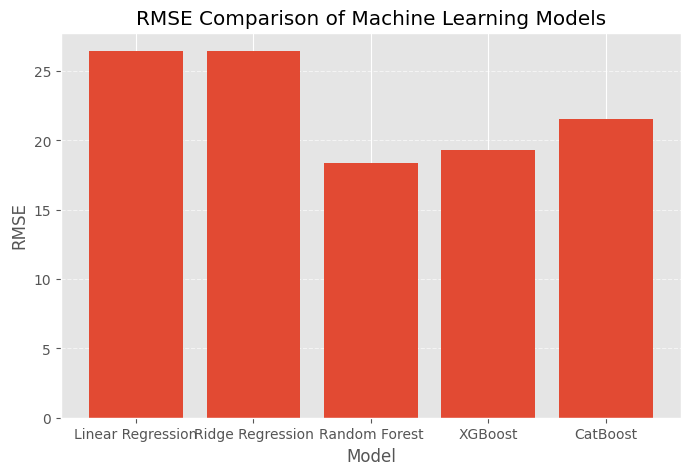

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Visualize the R² Score Comparison

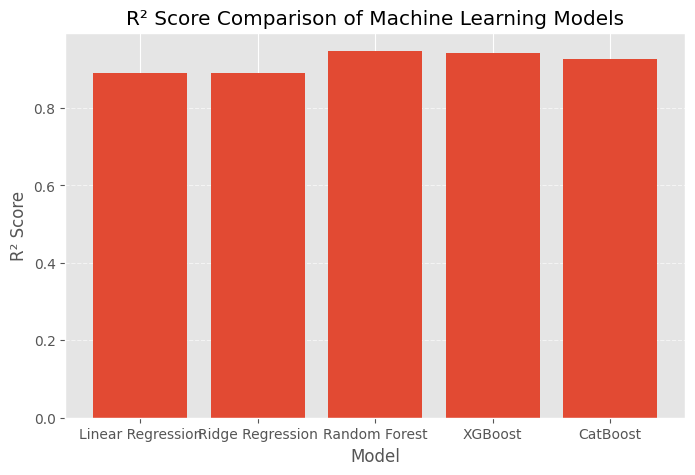

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("R² Score Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Identify the Best Performing Model

In [ ]:
best_model = results_df.loc[results_df["RMSE"].idxmin()]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model    Random Forest
MAE          12.021359
RMSE         18.398904
MAPE           0.16242
R2            0.947275
Name: 2, dtype: object


**Cross-City Generalization Experiment**

Prepare the Test Data for Unseen Cities

exact names of the cities in dataset

In [ ]:
df["City"].unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

filter the original dataset to get only the cities we want to test

In [ ]:
test_cities = ["Bengaluru", "Chennai", "Kolkata"]

test_df = df_model[df_model["City"].isin(test_cities)].copy()

print(test_df["City"].value_counts())

City
Bengaluru    2002
Chennai      2002
Kolkata       807
Name: count, dtype: int64


Create Separate Datasets for Each Test City

In [ ]:
bengaluru_df = test_df[test_df["City"] == "Bengaluru"].copy()
chennai_df = test_df[test_df["City"] == "Chennai"].copy()
kolkata_df = test_df[test_df["City"] == "Kolkata"].copy()

print("Bengaluru:", bengaluru_df.shape)
print("Chennai:", chennai_df.shape)
print("Kolkata:", kolkata_df.shape)

Bengaluru: (2002, 18)
Chennai: (2002, 18)
Kolkata: (807, 18)


Prepare the Features and Target for Each Test City

In [ ]:
X_bengaluru = bengaluru_df[feature_cols]
y_bengaluru = bengaluru_df[target]

X_chennai = chennai_df[feature_cols]
y_chennai = chennai_df[target]

X_kolkata = kolkata_df[feature_cols]
y_kolkata = kolkata_df[target]

Create a Reusable Evaluation Function

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, model_name, city_name):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mape = mean_absolute_percentage_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    return {
        "City": city_name,
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

In [ ]:
%who

CatBoostRegressor	 LinearRegression	 RandomForestRegressor	 Ridge	 SimpleImputer	 StandardScaler	 XGBRegressor	 X_bengaluru	 X_chennai	 
X_kolkata	 X_test	 X_train	 X_train_scaled	 X_val	 X_val_scaled	 bengaluru_df	 best_model	 cat	 
cat_mae	 cat_mape	 cat_pred	 cat_r2	 cat_results	 cat_rmse	 chennai_df	 city_missing	 df	 
df_clean	 df_model	 evaluate_model	 feature_cols	 features	 files	 imputer	 kolkata_df	 linear_results	 
lr	 mae	 mae_xgb	 mape	 mape_xgb	 mean_absolute_error	 mean_absolute_percentage_error	 mean_squared_error	 missing	 
np	 numeric_cols	 os	 pd	 plt	 r2	 r2_score	 r2_xgb	 results_df	 
rf	 rf_mae	 rf_mape	 rf_pred	 rf_r2	 rf_results	 rf_rmse	 ridge	 ridge_mae	 
ridge_mape	 ridge_pred	 ridge_r2	 ridge_results	 ridge_rmse	 rmse	 rmse_xgb	 scaler	 sns	 
split_index	 target	 test_cities	 test_df	 train_city	 train_df	 train_split	 uploaded	 val_split	 
warnings	 xgb	 xgb_results	 y_bengaluru	 y_chennai	 y_kolkata	 y_pred	 y_pred_xgb	 y_test	 
y_train	 y_val	 


Scale the Test Data

In [ ]:
X_bengaluru_scaled = scaler.transform(X_bengaluru)
X_chennai_scaled = scaler.transform(X_chennai)
X_kolkata_scaled = scaler.transform(X_kolkata)

Evaluate Models on Bengaluru

In [ ]:
bengaluru_results = [
    evaluate_model(lr, X_bengaluru_scaled, y_bengaluru, "Linear Regression", "Bengaluru"),
    evaluate_model(ridge, X_bengaluru_scaled, y_bengaluru, "Ridge Regression", "Bengaluru"),
    evaluate_model(rf, X_bengaluru, y_bengaluru, "Random Forest", "Bengaluru"),
    evaluate_model(xgb, X_bengaluru, y_bengaluru, "XGBoost", "Bengaluru"),
    evaluate_model(cat, X_bengaluru, y_bengaluru, "CatBoost", "Bengaluru")
]

pd.DataFrame(bengaluru_results)

,City,Model,MAE,RMSE,MAPE,R2
0,Bengaluru,Linear Regression,13.640784,20.456753,0.424362,0.225113
1,Bengaluru,Ridge Regression,13.632231,20.451619,0.424066,0.225501
2,Bengaluru,Random Forest,10.487580,17.585901,0.398272,0.427343
3,Bengaluru,XGBoost,14.439182,20.477046,0.567645,0.223574
4,Bengaluru,CatBoost,15.759784,21.286665,0.615897,0.160964


Evaluate Models on Chennai

In [ ]:
chennai_results = [
    evaluate_model(lr, X_chennai_scaled, y_chennai, "Linear Regression", "Chennai"),
    evaluate_model(ridge, X_chennai_scaled, y_chennai, "Ridge Regression", "Chennai"),
    evaluate_model(rf, X_chennai, y_chennai, "Random Forest", "Chennai"),
    evaluate_model(xgb, X_chennai, y_chennai, "XGBoost", "Chennai"),
    evaluate_model(cat, X_chennai, y_chennai, "CatBoost", "Chennai")
]

pd.DataFrame(chennai_results)

,City,Model,MAE,RMSE,MAPE,R2
0,Chennai,Linear Regression,28.564645,35.257999,0.530245,-0.023145
1,Chennai,Ridge Regression,28.558166,35.254835,0.530027,-0.022962
2,Chennai,Random Forest,17.380531,26.535070,0.323911,0.420488
3,Chennai,XGBoost,17.816010,26.280243,0.367618,0.431565
4,Chennai,CatBoost,16.405930,24.525721,0.353612,0.504931


Evaluate Models on Kolkata

In [ ]:
kolkata_results = [
    evaluate_model(lr, X_kolkata_scaled, y_kolkata, "Linear Regression", "Kolkata"),
    evaluate_model(ridge, X_kolkata_scaled, y_kolkata, "Ridge Regression", "Kolkata"),
    evaluate_model(rf, X_kolkata, y_kolkata, "Random Forest", "Kolkata"),
    evaluate_model(xgb, X_kolkata, y_kolkata, "XGBoost", "Kolkata"),
    evaluate_model(cat, X_kolkata, y_kolkata, "CatBoost", "Kolkata")
]

pd.DataFrame(kolkata_results)

,City,Model,MAE,RMSE,MAPE,R2
0,Kolkata,Linear Regression,14.319414,17.494427,0.537493,0.908695
1,Kolkata,Ridge Regression,14.307570,17.482832,0.536754,0.908816
2,Kolkata,Random Forest,11.063752,14.944790,0.489607,0.933369
3,Kolkata,XGBoost,13.032660,17.174472,0.634476,0.912004
4,Kolkata,CatBoost,13.017464,17.198341,0.624655,0.911760


Combine Results from All Cities

In [ ]:
cross_city_results = pd.concat([
    pd.DataFrame(bengaluru_results),
    pd.DataFrame(chennai_results),
    pd.DataFrame(kolkata_results)
], ignore_index=True)

cross_city_results

,City,Model,MAE,RMSE,MAPE,R2
0,Bengaluru,Linear Regression,13.640784,20.456753,0.424362,0.225113
1,Bengaluru,Ridge Regression,13.632231,20.451619,0.424066,0.225501
2,Bengaluru,Random Forest,10.487580,17.585901,0.398272,0.427343
3,Bengaluru,XGBoost,14.439182,20.477046,0.567645,0.223574
4,Bengaluru,CatBoost,15.759784,21.286665,0.615897,0.160964
5,Chennai,Linear Regression,28.564645,35.257999,0.530245,-0.023145
6,Chennai,Ridge Regression,28.558166,35.254835,0.530027,-0.022962
7,Chennai,Random Forest,17.380531,26.535070,0.323911,0.420488
8,Chennai,XGBoost,17.816010,26.280243,0.367618,0.431565
9,Chennai,CatBoost,16.405930,24.525721,0.353612,0.504931


Sort the Results

In [ ]:
cross_city_results.sort_values(
    by=["City", "RMSE"]
).reset_index(drop=True)

,City,Model,MAE,RMSE,MAPE,R2
0,Bengaluru,Random Forest,10.487580,17.585901,0.398272,0.427343
1,Bengaluru,Ridge Regression,13.632231,20.451619,0.424066,0.225501
2,Bengaluru,Linear Regression,13.640784,20.456753,0.424362,0.225113
3,Bengaluru,XGBoost,14.439182,20.477046,0.567645,0.223574
4,Bengaluru,CatBoost,15.759784,21.286665,0.615897,0.160964
5,Chennai,CatBoost,16.405930,24.525721,0.353612,0.504931
6,Chennai,XGBoost,17.816010,26.280243,0.367618,0.431565
7,Chennai,Random Forest,17.380531,26.535070,0.323911,0.420488
8,Chennai,Ridge Regression,28.558166,35.254835,0.530027,-0.022962
9,Chennai,Linear Regression,28.564645,35.257999,0.530245,-0.023145


Visualize Cross-City Performance (RMSE)

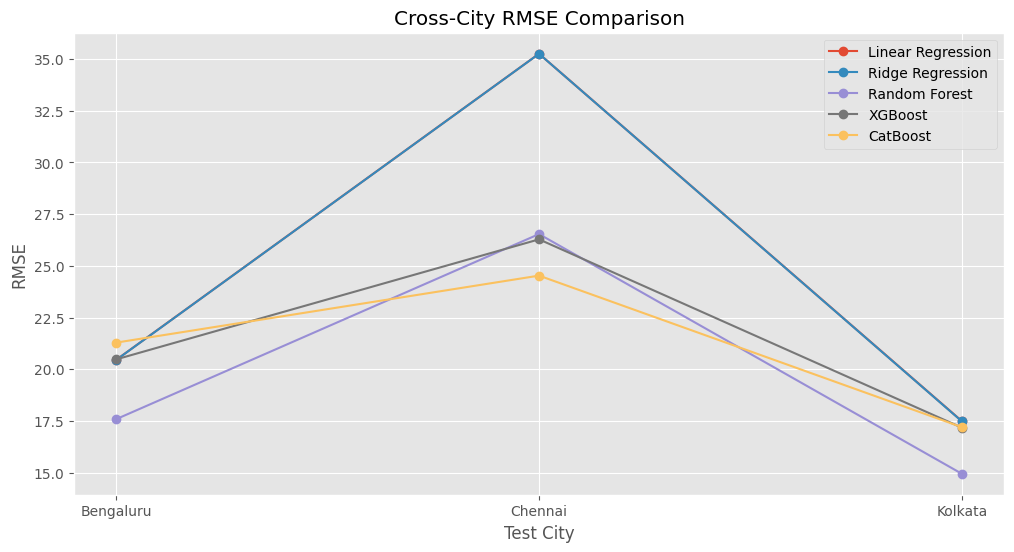

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for model in cross_city_results["Model"].unique():
    temp = cross_city_results[cross_city_results["Model"] == model]
    plt.plot(temp["City"], temp["RMSE"], marker="o", label=model)

plt.title("Cross-City RMSE Comparison")
plt.xlabel("Test City")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

Visualize Cross-City Performance (R²)

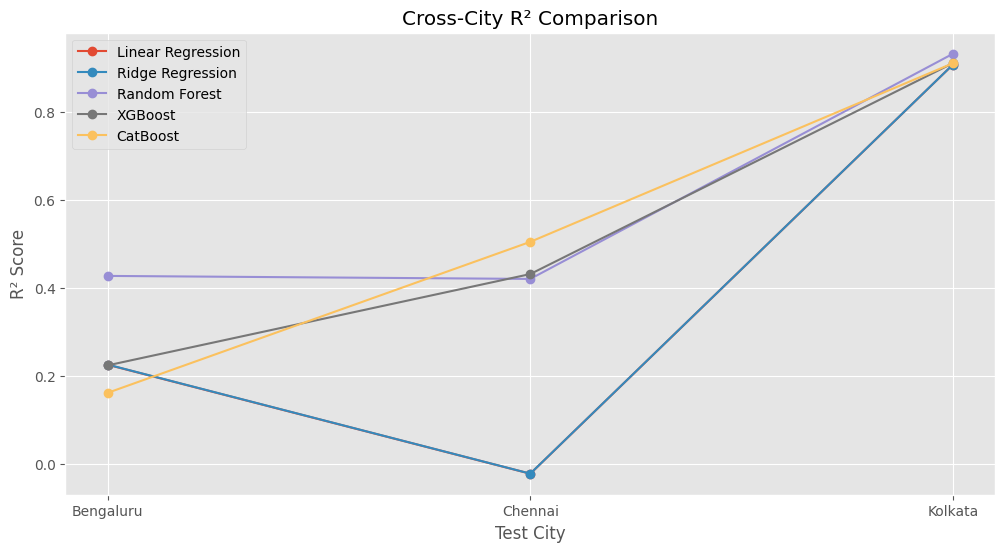

In [ ]:
plt.figure(figsize=(12,6))

for model in cross_city_results["Model"].unique():
    temp = cross_city_results[cross_city_results["Model"] == model]
    plt.plot(temp["City"], temp["R2"], marker="o", label=model)

plt.title("Cross-City R² Comparison")
plt.xlabel("Test City")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()

Conclusion

In [ ]:
best_models = cross_city_results.loc[
    cross_city_results.groupby("City")["RMSE"].idxmin()
]

best_models

,City,Model,MAE,RMSE,MAPE,R2
2,Bengaluru,Random Forest,10.487580,17.585901,0.398272,0.427343
9,Chennai,CatBoost,16.405930,24.525721,0.353612,0.504931
12,Kolkata,Random Forest,11.063752,14.944790,0.489607,0.933369


In [ ]:
print(best_models[["City", "Model", "RMSE", "R2"]])

         City          Model       RMSE        R2
2   Bengaluru  Random Forest  17.585901  0.427343
9     Chennai       CatBoost  24.525721  0.504931
12    Kolkata  Random Forest  14.944790  0.933369


**Compare Delhi vs Cross-City Performance**

create a DataFrame for the Delhi validation results.

In [ ]:
delhi_results = pd.DataFrame([
    linear_results,
    ridge_results,
    rf_results,
    xgb_results,
    cat_results
])

delhi_results["City"] = "Delhi (Validation)"

delhi_results

,Model,MAE,RMSE,MAPE,R2,City
0,Linear Regression,16.938773,26.449503,0.216180,0.891040,Delhi (Validation)
1,Ridge Regression,16.931022,26.450039,0.215947,0.891035,Delhi (Validation)
2,Random Forest,12.021359,18.398904,0.162420,0.947275,Delhi (Validation)
3,XGBoost,12.578717,19.307195,0.164282,0.941941,Delhi (Validation)
4,CatBoost,13.778038,21.572814,0.181442,0.927515,Delhi (Validation)


Now combine Delhi with the cross-city results.


In [ ]:
all_results = pd.concat([
    delhi_results,
    cross_city_results
], ignore_index=True)

all_results

,Model,MAE,RMSE,MAPE,R2,City
0,Linear Regression,16.938773,26.449503,0.216180,0.891040,Delhi (Validation)
1,Ridge Regression,16.931022,26.450039,0.215947,0.891035,Delhi (Validation)
2,Random Forest,12.021359,18.398904,0.162420,0.947275,Delhi (Validation)
3,XGBoost,12.578717,19.307195,0.164282,0.941941,Delhi (Validation)
4,CatBoost,13.778038,21.572814,0.181442,0.927515,Delhi (Validation)
5,Linear Regression,13.640784,20.456753,0.424362,0.225113,Bengaluru
6,Ridge Regression,13.632231,20.451619,0.424066,0.225501,Bengaluru
7,Random Forest,10.487580,17.585901,0.398272,0.427343,Bengaluru
8,XGBoost,14.439182,20.477046,0.567645,0.223574,Bengaluru
9,CatBoost,15.759784,21.286665,0.615897,0.160964,Bengaluru


create a comparison plot.

RMSE Across Cities

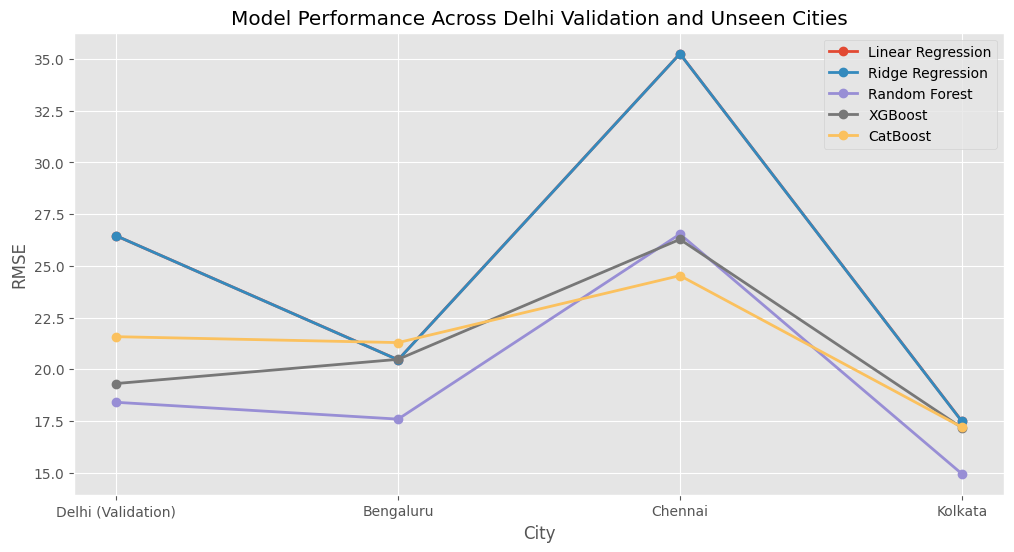

In [ ]:
plt.figure(figsize=(12,6))

for model in all_results["Model"].unique():
    temp = all_results[all_results["Model"] == model]
    plt.plot(temp["City"], temp["RMSE"], marker="o", linewidth=2, label=model)

plt.title("Model Performance Across Delhi Validation and Unseen Cities")
plt.xlabel("City")
plt.ylabel("RMSE")
plt.grid(True)
plt.legend()
plt.show()

R² Across Cities

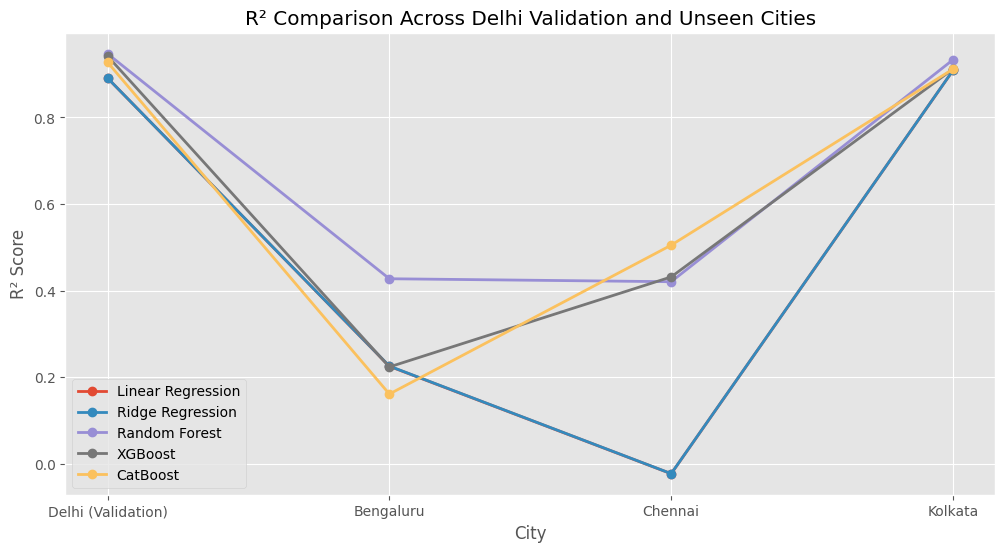

In [ ]:
plt.figure(figsize=(12,6))

for model in all_results["Model"].unique():
    temp = all_results[all_results["Model"] == model]
    plt.plot(temp["City"], temp["R2"], marker="o", linewidth=2, label=model)

plt.title("R² Comparison Across Delhi Validation and Unseen Cities")
plt.xlabel("City")
plt.ylabel("R² Score")
plt.grid(True)
plt.legend()
plt.show()

# Research **Findings** and **Discussion**

In [ ]:
print("=" * 70)
print("Research Findings and Discussion")
print("=" * 70)

print("""
1. Random Forest achieved the best performance on the Delhi validation dataset,
   with the lowest RMSE (18.40) and the highest R² score (0.9473), making it
   the most effective model during the model selection phase.

2. When evaluated on unseen cities, Random Forest remained the best-performing
   model for Bengaluru and Kolkata, demonstrating strong cross-city
   generalization and robustness.

3. CatBoost outperformed all other models on Chennai, indicating that
   different cities may exhibit distinct pollution patterns and that no
   single model is universally optimal for every geographical region.

4. Linear Regression and Ridge Regression consistently produced higher errors
   than ensemble-based models, suggesting that the relationship between
   air pollutants and PM2.5 concentration is nonlinear and better captured
   by tree-based machine learning algorithms.

5. Although model performance varied across cities, the ensemble models
   maintained competitive prediction accuracy without being retrained on the
   target cities, demonstrating their ability to generalize to unseen
   geographical locations.

Conclusion:
The experimental results indicate that machine learning models trained on
Delhi can successfully generalize to other Indian cities. Among the evaluated
models, Random Forest emerged as the most consistent performer across multiple
cities, while CatBoost showed superior performance for Chennai. These findings
highlight the importance of evaluating models on geographically distinct
datasets when developing air quality forecasting systems for real-world
deployment.
""")

Research Findings and Discussion

1. Random Forest achieved the best performance on the Delhi validation dataset,
   with the lowest RMSE (18.40) and the highest R² score (0.9473), making it
   the most effective model during the model selection phase.

2. When evaluated on unseen cities, Random Forest remained the best-performing
   model for Bengaluru and Kolkata, demonstrating strong cross-city
   generalization and robustness.

3. CatBoost outperformed all other models on Chennai, indicating that
   different cities may exhibit distinct pollution patterns and that no
   single model is universally optimal for every geographical region.

4. Linear Regression and Ridge Regression consistently produced higher errors
   than ensemble-based models, suggesting that the relationship between
   air pollutants and PM2.5 concentration is nonlinear and better captured
   by tree-based machine learning algorithms.

5. Although model performance varied across cities, the ensemble models
   main

**Project Conclusion**

This project developed and evaluated multiple machine learning models for PM2.5 forecasting using air quality data from Indian cities. Beyond achieving high predictive performance on the training city, the study investigated whether models trained on Delhi could generalize to geographically distinct cities without retraining.

Experimental results demonstrated that ensemble-based models consistently outperformed traditional linear models. Random Forest achieved the best overall performance, while CatBoost provided superior predictions for Chennai. The cross-city evaluation highlights that although predictive accuracy varies across regions due to differences in pollution characteristics, machine learning models can effectively generalize to unseen cities.

The proposed workflow—including data preprocessing, feature engineering, time-based validation, multi-model comparison, and cross-city evaluation—provides a comprehensive framework for developing robust air quality prediction systems that can support environmental monitoring and smart city applications.

**Save the Best Model**

In [ ]:
import joblib

joblib.dump(rf, "best_random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


Save the Scaler

In [ ]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


Save the Feature Names

In [ ]:
joblib.dump(feature_cols, "feature_columns.pkl")

print("Feature columns saved successfully!")

Feature columns saved successfully!


Save the Imputer

In [ ]:
SimpleImputer(strategy="median")

SimpleImputer(strategy='median')

In [ ]:
joblib.dump(imputer, "imputer.pkl")

print("Imputer saved successfully!")

Imputer saved successfully!
